## 📦 Bước 0 — Cài đặt thư viện

In [1]:
!pip install duckdb catboost shap imbalanced-learn scikit-learn pandas numpy matplotlib seaborn plotly --quiet optuna catboost shap duckdb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 9.4 MB/s eta 0:00:00


## 🔑 Bước 1 — Kết nối MotherDuck & Đọc dữ liệu Gold

In [2]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from google.colab import userdata

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid")

# 1. Lấy token từ Colab Secrets
MOTHERDUCK_TOKEN = userdata.get("motherduck")

# Kiểm tra
if MOTHERDUCK_TOKEN is None:
    raise ValueError("Không tìm thấy Secret 'motherduck'")

# 2. Kết nối MotherDuck
con = duckdb.connect(
    f"md:my_db?motherduck_token={MOTHERDUCK_TOKEN}"
)

# 3. Attach Database Share
try:
    con.execute("""
        ATTACH 'md:_share/Vanh_gold/f62b77cb-934f-4e65-924c-2ba9366507da'
        AS vanh_gold (READ_ONLY)
    """)
    print("✅ Đã kết nối vanh_gold thành công!")
except Exception:
    print("ℹ️ Database đã được attach trước đó.")

# 4. Load dữ liệu
df = con.execute("""
    SELECT *
    FROM vanh_gold.wide_table_ml
""").df()

print(f"✅ Đã load {len(df):,} dòng × {df.shape[1]} cột")
display(df.head())

ℹ️ Database đã được attach trước đó.
✅ Đã load 114,187 dòng × 24 cột


,order_id,customer_segment,customer_country,customer_state,shipping_mode,market,order_region,order_type,category_name,department_name,...,order_item_quantity,days_for_shipment_scheduled,order_month,order_quarter,order_weekday,profit_margin,discount_ratio,sales_per_item,is_weekend,late_delivery_risk
0,77202,CONSUMER,PUERTO RICO,PR,Standard Class,PACIFIC ASIA,SOUTHEAST ASIA,DEBIT,Sporting Goods,Fitness,...,1,4,1,1,3,0.278413,0.040000,327.75,0,0
1,75937,HOME OFFICE,EE. UU.,CA,Standard Class,PACIFIC ASIA,OCEANIA,DEBIT,Sporting Goods,Fitness,...,1,4,1,1,6,0.069748,0.069992,327.75,1,0
2,75936,CORPORATE,PUERTO RICO,PR,Standard Class,PACIFIC ASIA,OCEANIA,PAYMENT,Sporting Goods,Fitness,...,1,4,1,1,6,0.409489,0.090008,327.75,1,0
3,75935,CONSUMER,EE. UU.,NY,Standard Class,PACIFIC ASIA,OCEANIA,TRANSFER,Sporting Goods,Fitness,...,1,4,1,1,6,0.056690,0.100015,327.75,1,0
4,75934,HOME OFFICE,PUERTO RICO,PR,First Class,PACIFIC ASIA,EASTERN ASIA,DEBIT,Sporting Goods,Fitness,...,1,1,1,1,6,0.290404,0.120000,327.75,1,1


In [ ]:
# Load toàn bộ cột
df = con.execute("""
    SELECT *
    FROM vanh_gold.wide_table_ml
""").df()

print(f'✅ Đã load {len(df):,} dòng × {df.shape[1]} cột')

# Xem danh sách cột
print(df.columns.tolist())

df.head()

✅ Đã load 114,187 dòng × 24 cột
['order_id', 'customer_segment', 'customer_country', 'customer_state', 'shipping_mode', 'market', 'order_region', 'order_type', 'category_name', 'department_name', 'product_price', 'sales_amount', 'profit', 'discount', 'order_item_quantity', 'days_for_shipment_scheduled', 'order_month', 'order_quarter', 'order_weekday', 'profit_margin', 'discount_ratio', 'sales_per_item', 'is_weekend', 'late_delivery_risk']


,order_id,customer_segment,customer_country,customer_state,shipping_mode,market,order_region,order_type,category_name,department_name,...,order_item_quantity,days_for_shipment_scheduled,order_month,order_quarter,order_weekday,profit_margin,discount_ratio,sales_per_item,is_weekend,late_delivery_risk
0,77202,CONSUMER,PUERTO RICO,PR,Standard Class,PACIFIC ASIA,SOUTHEAST ASIA,DEBIT,Sporting Goods,Fitness,...,1,4,1,1,3,0.278413,0.040000,327.75,0,0
1,75937,HOME OFFICE,EE. UU.,CA,Standard Class,PACIFIC ASIA,OCEANIA,DEBIT,Sporting Goods,Fitness,...,1,4,1,1,6,0.069748,0.069992,327.75,1,0
2,75936,CORPORATE,PUERTO RICO,PR,Standard Class,PACIFIC ASIA,OCEANIA,PAYMENT,Sporting Goods,Fitness,...,1,4,1,1,6,0.409489,0.090008,327.75,1,0
3,75935,CONSUMER,EE. UU.,NY,Standard Class,PACIFIC ASIA,OCEANIA,TRANSFER,Sporting Goods,Fitness,...,1,4,1,1,6,0.056690,0.100015,327.75,1,0
4,75934,HOME OFFICE,PUERTO RICO,PR,First Class,PACIFIC ASIA,EASTERN ASIA,DEBIT,Sporting Goods,Fitness,...,1,1,1,1,6,0.290404,0.120000,327.75,1,1


## 🔧 Bước 3 — Feature Engineering & Preprocessing

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Định nghĩa các nhóm đặc trưng
CAT_FEATURES = ['customer_segment', 'customer_country', 'shipping_mode', 'market',
                'order_region', 'order_type', 'category_name', 'department_name',
                'customer_state', 'is_weekend', 'order_weekday', 'order_month', 'order_quarter']
NUM_FEATURES = ['product_price', 'sales_amount', 'profit', 'discount',
                'order_item_quantity', 'days_for_shipment_scheduled', 'profit_margin']
TARGET = 'late_delivery_risk'

# Tiền xử lý
df_ml = df[CAT_FEATURES + NUM_FEATURES + [TARGET]].dropna().copy()
for col in CAT_FEATURES:
    df_ml[col] = df_ml[col].astype(str)

X = df_ml.drop(columns=[TARGET])
y = df_ml[TARGET].astype(int)
cat_idx = [X.columns.get_loc(c) for c in CAT_FEATURES]

# Chia dữ liệu
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

# Bảng thống kê
split_summary = pd.DataFrame({
    "Tập dữ liệu": ["Train", "Validation", "Test", "Tổng"],
    "Số lượng mẫu": [len(X_train), len(X_val), len(X_test), len(df_ml)],
    "Tỷ lệ (%)": [
        len(X_train)/len(df_ml)*100,
        len(X_val)/len(df_ml)*100,
        len(X_test)/len(df_ml)*100,
        100
    ]
})

split_summary["Tỷ lệ (%)"] = split_summary["Tỷ lệ (%)"].map(lambda x: f"{x:.1f}%")

display(split_summary)

,Tập dữ liệu,Số lượng mẫu,Tỷ lệ (%)
0,Train,68511,60.0%
1,Validation,22838,20.0%
2,Test,22838,20.0%
3,Tổng,114187,100.0%


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
save_path="/content/drive/Shareddrives/5 CÔ GÁI/NĂM 3/KÌ 3/NHÀ KHO DỮ LIỆU"
# Gộp X và y để lưu cho đồng bộ
train_df = X_train.copy()
train_df[TARGET] = y_train

val_df = X_val.copy()
val_df[TARGET] = y_val

test_df = X_test.copy()
test_df[TARGET] = y_test

# Lưu ra file CSV
train_df.to_csv(f"{save_path}/train_data.csv", index=False)
val_df.to_csv(f"{save_path}/val_data.csv", index=False)
test_df.to_csv(f"{save_path}/test_data.csv", index=False)

⏳ Đang huấn luyện Baseline Models...


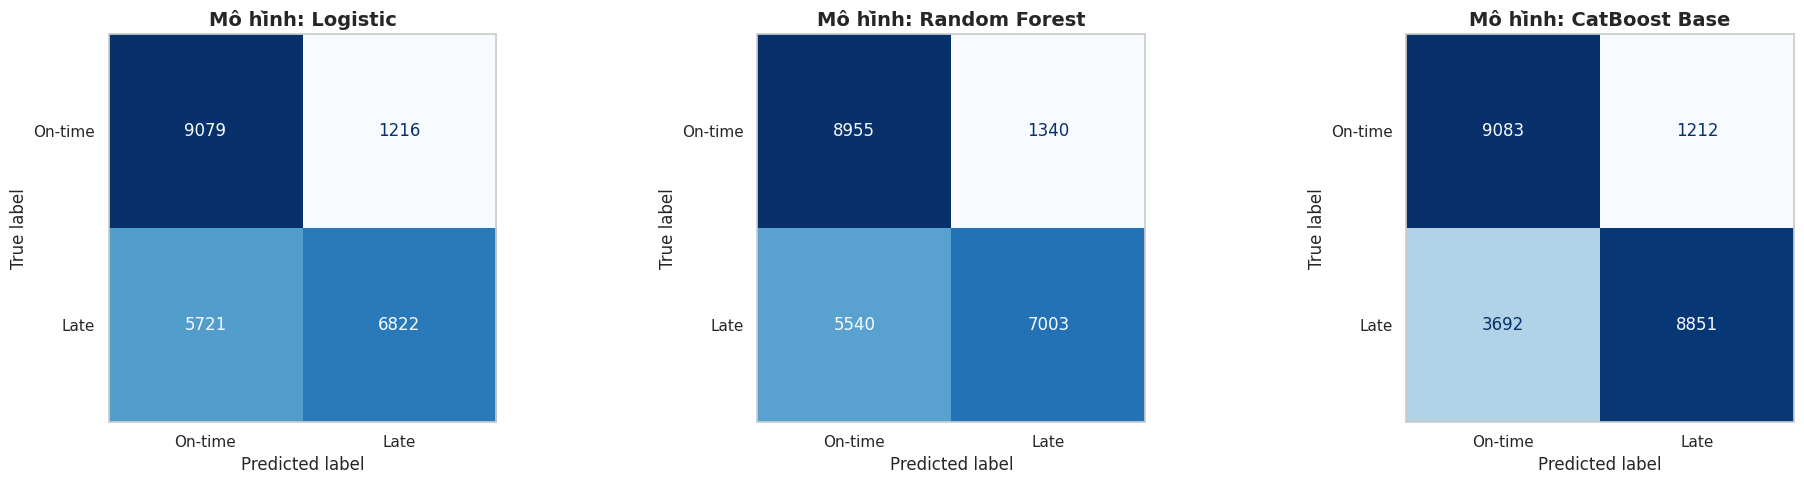

,Model,Train AUC,Val AUC,Diff AUC,Val Precision,Val Recall,Val F1,Val Acc
2,CatBoost Base,0.9359,0.8820,0.0539,0.8796,0.7057,0.7831,0.7853
1,Random Forest,0.8292,0.7504,0.0788,0.8394,0.5583,0.6706,0.6987
0,Logistic,0.7464,0.7450,0.0014,0.8487,0.5439,0.6629,0.6963



🏆 Model tốt nhất dựa trên Val AUC: CatBoost Base


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                             precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay)
import pandas as pd
import matplotlib.pyplot as plt

# 1. Định nghĩa Tiền xử lý
lr_pre = ColumnTransformer([
    ('n', StandardScaler(), NUM_FEATURES),
    ('c', OneHotEncoder(handle_unknown='ignore'), CAT_FEATURES)
])
lr_model = Pipeline([
    ('pre', lr_pre),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

rf_pre = ColumnTransformer([
    ('c', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), CAT_FEATURES)
], remainder='passthrough')
rf_model = Pipeline([
    ('pre', rf_pre),
    ('clf', RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1))
])

cb_model = CatBoostClassifier(
    iterations=300, verbose=0, cat_features=cat_idx,
    auto_class_weights='Balanced', task_type="CPU", random_seed=42 # Đổi GPU nếu có
)

# 2. Huấn luyện và Đánh giá
baseline_res, trained_models = [], {}
models = [('Logistic', lr_model), ('Random Forest', rf_model), ('CatBoost Base', cb_model)]

# Thiết lập figure để vẽ Confusion Matrix side-by-side
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

print("⏳ Đang huấn luyện Baseline Models...")

for i, (name, model) in enumerate(models):
    model.fit(X_train, y_train)

    # Dự báo
    prob_train = model.predict_proba(X_train)[:, 1]
    prob_val = model.predict_proba(X_val)[:, 1]
    pred_val = (prob_val > 0.5).astype(int)

    # Tính toán chỉ số
    auc_train = roc_auc_score(y_train, prob_train)
    auc_val = roc_auc_score(y_val, prob_val)
    precision = precision_score(y_val, pred_val)
    recall = recall_score(y_val, pred_val)
    f1 = f1_score(y_val, pred_val)
    acc = accuracy_score(y_val, pred_val)

    baseline_res.append({
        'Model': name,
        'Train AUC': round(auc_train, 4),
        'Val AUC': round(auc_val, 4),
        'Diff AUC': round(auc_train - auc_val, 4),
        'Val Precision': round(precision, 4),
        'Val Recall': round(recall, 4),
        'Val F1': round(f1, 4),
        'Val Acc': round(acc, 4)
    })
    trained_models[name] = model

    # --- VẼ CONFUSION MATRIX ---
    cm = confusion_matrix(y_val, pred_val)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On-time', 'Late'])

    # Vẽ lên trục tương ứng
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)

    # QUAN TRỌNG: Dòng này để xóa đường kẻ trong ô vuông
    axes[i].grid(False)

    axes[i].set_title(f'Mô hình: {name}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# 3. Hiển thị bảng kết quả
df_res = pd.DataFrame(baseline_res).sort_values(by='Val AUC', ascending=False)
display(df_res)

# Nhận xét nhanh
best_model = df_res.iloc[0]['Model']
print(f"\n🏆 Model tốt nhất dựa trên Val AUC: {best_model}")

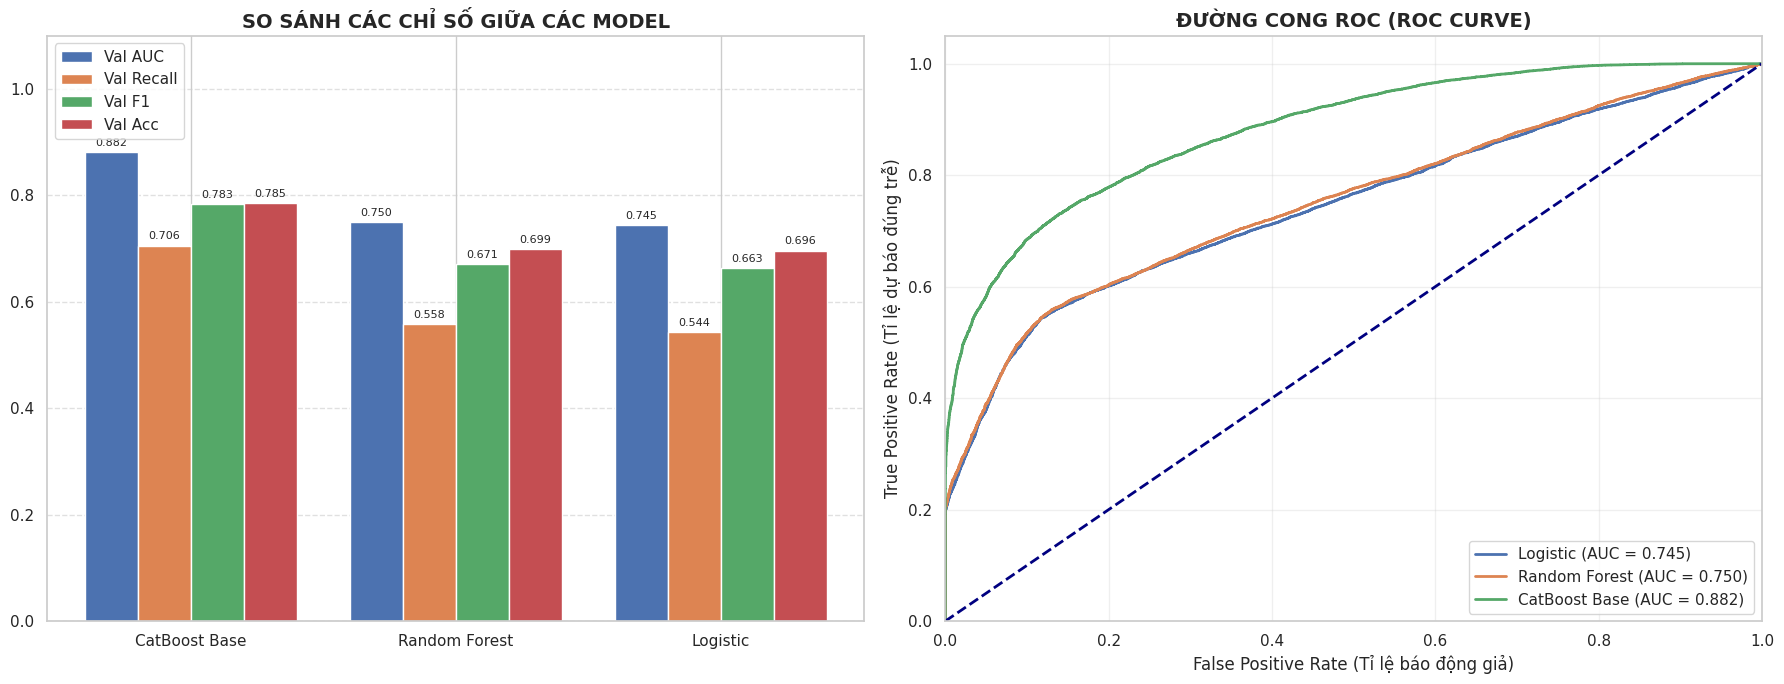

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc

# Thiết lập layout gồm 1 hàng 2 cột
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# ---------------------------------------------------------
# BIỂU ĐỒ 1: GROUPED BAR CHART (Khớp với tên cột của bạn)
# ---------------------------------------------------------
# Cập nhật tên cột chính xác từ DataFrame df_res của bạn
metrics_cols = ['Val AUC', 'Val Recall', 'Val F1', 'Val Acc']
x = np.arange(len(df_res))
width = 0.2 # Độ rộng của cột

for i, col in enumerate(metrics_cols):
    bars = ax1.bar(x + i*width, df_res[col], width, label=col)
    ax1.bar_label(bars, padding=3, fmt='%.3f', fontsize=8)

ax1.set_title('SO SÁNH CÁC CHỈ SỐ GIỮA CÁC MODEL', fontsize=14, fontweight='bold')
ax1.set_xticks(x + width*1.5)
ax1.set_xticklabels(df_res['Model'])
ax1.set_ylim(0, 1.1)
ax1.legend(loc='upper left')
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# ---------------------------------------------------------
# BIỂU ĐỒ 2: ROC CURVE
# ---------------------------------------------------------
for name, model in trained_models.items():
    # Lấy xác suất dự báo
    y_prob = model.predict_proba(X_val)[:, 1]

    fpr, tpr, _ = roc_curve(y_val, y_prob)
    roc_auc = auc(fpr, tpr)
    ax2.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate (Tỉ lệ báo động giả)')
ax2.set_ylabel('True Positive Rate (Tỉ lệ dự báo đúng trễ)')
ax2.set_title('ĐƯỜNG CONG ROC (ROC CURVE)', fontsize=14, fontweight='bold')
ax2.legend(loc="lower right")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import optuna
from optuna.samplers import TPESampler
import numpy as np
from sklearn.metrics import precision_recall_curve, roc_auc_score
from catboost import CatBoostClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "iterations"        : trial.suggest_int("iterations", 400, 1000),
        "learning_rate"     : trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "depth"             : trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg"       : trial.suggest_float("l2_leaf_reg", 1, 20),
        "random_strength"   : trial.suggest_float("random_strength", 0.1, 5),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 5),
        "loss_function"     : "Logloss",
        "eval_metric"       : "AUC",
        "task_type"         : "GPU",
        "random_seed"       : 42,
        "verbose"           : False,
        "auto_class_weights": "Balanced",
    }
    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train, eval_set=(X_val, y_val),
              cat_features=cat_idx, early_stopping_rounds=50)
    return roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

print("🚀 Running Optuna Optimization (Stable Version)...")
study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=30)
print(f"✅ Best Val AUC : {study.best_value:.4f}")
print(f"✅ Best Params  : {study.best_params}")

FIXED_PARAMS = {
    **study.best_params,
    "loss_function"     : "Logloss",
    "eval_metric"       : "AUC",
    "task_type"         : "GPU",
    "random_seed"       : 42,
    "verbose"           : 0,
    "auto_class_weights": "Balanced",
}

# BƯỚC 2: Tìm Threshold tối ưu trên Val
threshold_finder = CatBoostClassifier(**FIXED_PARAMS)
threshold_finder.fit(X_train, y_train, cat_features=cat_idx)

val_prob = threshold_finder.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, val_prob)
f1_scores = (2 * precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)
best_threshold = float(thresholds[np.argmax(f1_scores)])
print(f"✅ Optimal Threshold = {best_threshold:.4f} (Maximizing F1 on Val set)")

# BƯỚC 3: Final Model train trên Train + Val
print("⏳ Training Final Model on (Train + Val)...")
final_model = CatBoostClassifier(**FIXED_PARAMS)
final_model.fit(X_train_val, y_train_val, cat_features=cat_idx)

trained_models['CatBoost Tuned'] = final_model
trained_models['best_threshold'] = best_threshold

print("🔥 All done! final_model & best_threshold sẵn sàng.")

🚀 Running Optuna Optimization (Stable Version)...


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric perio

✅ Best Val AUC : 0.8739
✅ Best Params  : {'iterations': 986, 'learning_rate': 0.06485618348127573, 'depth': 6, 'l2_leaf_reg': 8.212480624984245, 'random_strength': 3.266647816247124, 'bagging_temperature': 0.026546585467778105}


Default metric period is 5 because AUC is/are not implemented for GPU


✅ Optimal Threshold = 0.3633 (Maximizing F1 on Val set)
⏳ Training Final Model on (Train + Val)...


Default metric period is 5 because AUC is/are not implemented for GPU


🔥 All done! final_model & best_threshold sẵn sàng.


📊 KẾT QUẢ TEST - CatBoost Tuned (Threshold Optimized):
              precision    recall  f1-score   support

           0       0.80      0.70      0.75     10295
           1       0.78      0.85      0.81     12543

    accuracy                           0.79     22838
   macro avg       0.79      0.78      0.78     22838
weighted avg       0.79      0.79      0.78     22838



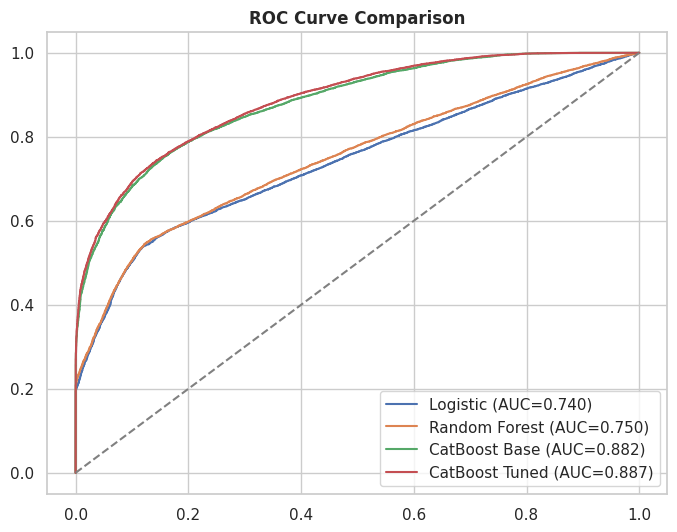

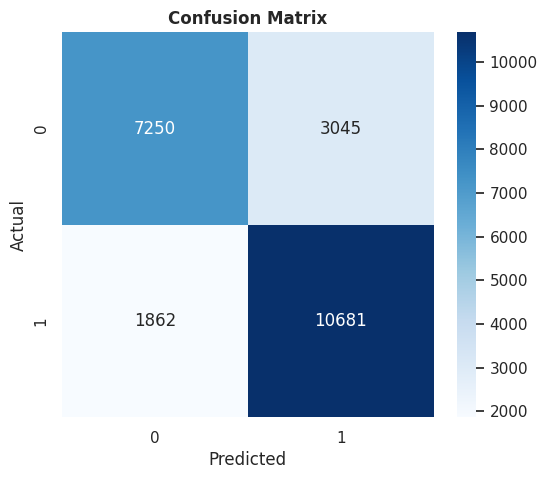

In [ ]:
from sklearn.metrics import classification_report, roc_curve, confusion_matrix, roc_auc_score, accuracy_score

y_prob_test = final_model.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test > best_threshold).astype(int)

print("📊 KẾT QUẢ TEST - CatBoost Tuned (Threshold Optimized):")
print(classification_report(y_test, y_pred_test))

# ROC Curve
plt.figure(figsize=(8, 6))
for name, model in trained_models.items():
    if name == 'best_threshold':
        continue
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, prob):.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title("ROC Curve Comparison", fontweight='bold')
plt.legend()
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

TN, FP, FN, TP = cm.ravel()

⏳ Đang xếp hạng các biến bằng thuật toán RecursiveByLossFunctionChange...
Step #1 out of 1
bestTest = 0.4355555981
bestIteration = 993
Feature #19 eliminated
Feature #13 eliminated
Feature #15 eliminated
Feature #17 eliminated
Feature #16 eliminated
Feature #9 eliminated
Feature #6 eliminated
Feature #7 eliminated
Feature #14 eliminated
Feature #1 eliminated
Feature #12 eliminated
Feature #3 eliminated
Feature #18 eliminated
Feature #0 eliminated
Feature #11 eliminated
Feature #10 eliminated
Feature #4 eliminated
Feature #5 eliminated
Feature #8 eliminated
⏳ Bắt đầu Quét cạn kiệt hiệu suất từ k=5 đến k=20...
  > k= 5: Mean CV AUC = 0.8459
  > k= 6: Mean CV AUC = 0.8832
  > k= 7: Mean CV AUC = 0.8916
  > k= 8: Mean CV AUC = 0.8916
  > k= 9: Mean CV AUC = 0.8890
  > k=10: Mean CV AUC = 0.8870
  > k=11: Mean CV AUC = 0.8870
  > k=12: Mean CV AUC = 0.8836
  > k=13: Mean CV AUC = 0.8813
  > k=14: Mean CV AUC = 0.8823
  > k=15: Mean CV AUC = 0.8821
  > k=16: Mean CV AUC = 0.8801
  > k=17: Me

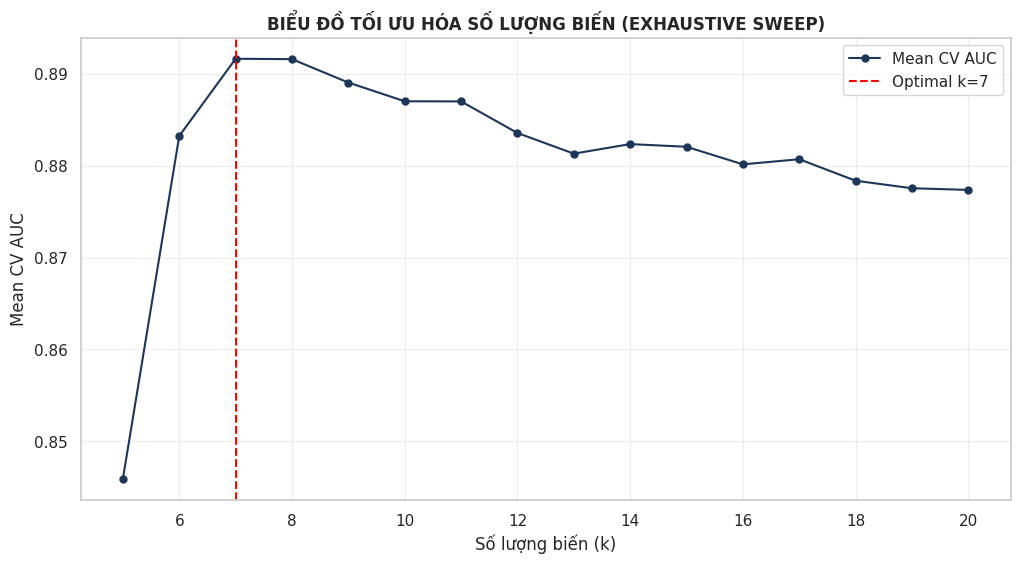


🏆 KẾT QUẢ TỐI ƯU TUYỆT ĐỐI:
Số lượng biến (k) tốt nhất: 7
Mean CV AUC cao nhất: 0.8916
Danh sách biến: ['shipping_mode', 'customer_state', 'order_type', 'order_region', 'order_weekday', 'order_month', 'customer_segment']


In [ ]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Tạo bảng xếp hạng Feature Importance bằng Native Select của CatBoost
full_pool = Pool(X_train, y_train, cat_features=cat_idx)
eval_pool = Pool(X_val, y_val, cat_features=cat_idx)

base_model = CatBoostClassifier(**study.best_params, task_type="GPU", random_seed=42, verbose=False)

print("⏳ Đang xếp hạng các biến bằng thuật toán RecursiveByLossFunctionChange...")
feature_selection_result = base_model.select_features(
    full_pool,
    eval_set=eval_pool,
    features_for_select=list(range(X_train.shape[1])),
    num_features_to_select=1, # Giữ lại 1 để ép CatBoost xếp hạng toàn bộ các biến còn lại
    algorithm='RecursiveByLossFunctionChange',
    train_final_model=False,
    verbose=False
)

# 2. Lấy danh sách toàn bộ biến đã được sắp xếp từ TỐT NHẤT đến TỆ NHẤT
# 'selected_features_names' chứa biến tốt nhất còn lại
# 'eliminated_features_names' chứa các biến bị loại theo thứ tự từ tệ nhất đến tốt dần
# => Đảo ngược eliminated và cộng với selected sẽ ra danh sách từ Tốt đến Tệ.
all_features_ranked = feature_selection_result['selected_features_names'] + feature_selection_result['eliminated_features_names'][::-1]

# 3. Bắt đầu Quét cạn kiệt (Exhaustive Sweep)
sweep_results = []
max_features = len(all_features_ranked)

print(f"⏳ Bắt đầu Quét cạn kiệt hiệu suất từ k=5 đến k={max_features}...")

for k in range(5, max_features + 1):
    current_feats = all_features_ranked[:k]

    # Đánh giá bằng 5-Fold Cross Validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_aucs = []

    for t_idx, v_idx in skf.split(X_train_val[current_feats], y_train_val):
        xt, xv = X_train_val[current_feats].iloc[t_idx], X_train_val[current_feats].iloc[v_idx]
        yt, yv = y_train_val.iloc[t_idx], y_train_val.iloc[v_idx]

        # Xác định lại index của biến categorical trong tập con hiện tại
        c_idx_sub = [current_feats.index(f) for f in CAT_FEATURES if f in current_feats]

        cv_model = CatBoostClassifier(
            **study.best_params, task_type="GPU", auto_class_weights='Balanced',
            random_seed=42, verbose=False, cat_features=c_idx_sub
        )
        cv_model.fit(xt, yt)
        fold_aucs.append(roc_auc_score(yv, cv_model.predict_proba(xv)[:, 1]))

    mean_auc = np.mean(fold_aucs)
    sweep_results.append({'k': k, 'auc': mean_auc, 'features': current_feats})
    print(f"  > k={k:>2}: Mean CV AUC = {mean_auc:.4f}")

# 4. Vẽ biểu đồ Performance Curve
df_sweep = pd.DataFrame(sweep_results)
plt.figure(figsize=(12, 6))
plt.plot(df_sweep['k'], df_sweep['auc'], marker='o', color='#1D3557', markersize=5, label='Mean CV AUC')
best_k = df_sweep.loc[df_sweep['auc'].idxmax(), 'k']
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Optimal k={best_k}')
plt.title('BIỂU ĐỒ TỐI ƯU HÓA SỐ LƯỢNG BIẾN (EXHAUSTIVE SWEEP)', fontweight='bold')
plt.xlabel('Số lượng biến (k)'); plt.ylabel('Mean CV AUC'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

# 5. Chốt bộ biến tốt nhất
best_k_row = df_sweep.loc[df_sweep['auc'].idxmax()]
best_features = best_k_row['features']
cat_idx_sel = [best_features.index(f) for f in CAT_FEATURES if f in best_features]

print(f"\n🏆 KẾT QUẢ TỐI ƯU TUYỆT ĐỐI:")
print(f"Số lượng biến (k) tốt nhất: {best_k_row['k']}")
print(f"Mean CV AUC cao nhất: {best_k_row['auc']:.4f}")
print(f"Danh sách biến: {best_features}")

KẾT QUẢ TỐI ƯU NGƯỠNG PHÂN LOẠI
Threshold mặc định : 0.5000
Threshold tối ưu    : 0.3522
Precision           : 0.7752
Recall              : 0.8640
F1-score            : 0.8172


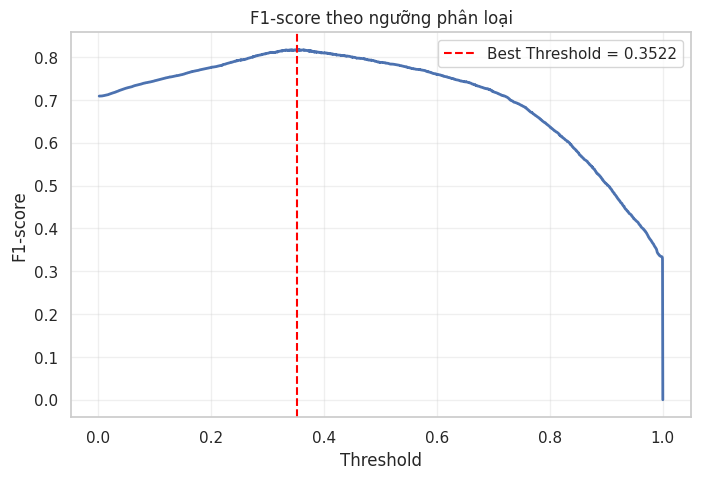


⏳ Huấn luyện Final Model với 7 đặc trưng...

BÁO CÁO KẾT QUẢ TRÊN TẬP TEST
              precision    recall  f1-score   support

           0       0.82      0.70      0.76     10295
           1       0.78      0.88      0.83     12543

    accuracy                           0.80     22838
   macro avg       0.80      0.79      0.79     22838
weighted avg       0.80      0.80      0.79     22838

ROC-AUC : 0.9016


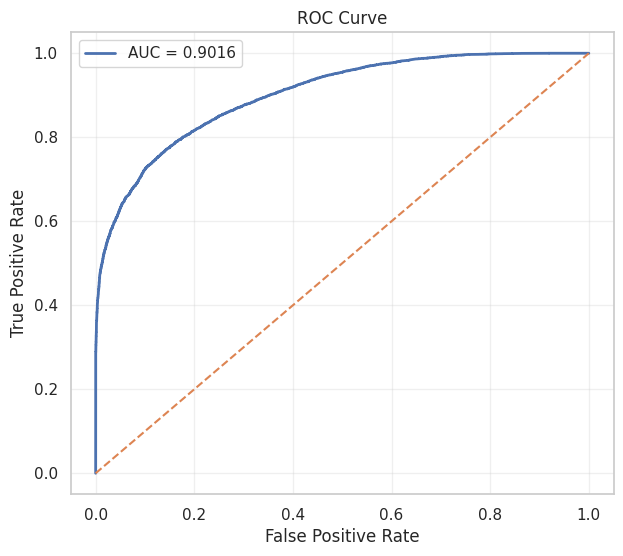

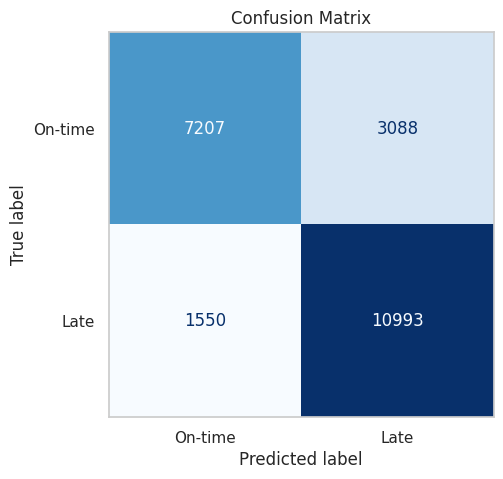

In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import (
    precision_recall_curve,
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# 1. Tìm Threshold tối ưu trên Validation
# ==========================================================

val_model = CatBoostClassifier(
    **study.best_params,
    task_type="GPU",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=False,
    cat_features=cat_idx_sel
)

val_model.fit(X_train[best_features], y_train)

val_prob = val_model.predict_proba(X_val[best_features])[:, 1]

prec, rec, threshs = precision_recall_curve(y_val, val_prob)

f1s = (2 * prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-9)

best_idx = np.argmax(f1s)
best_threshold = float(threshs[best_idx])

print("="*55)
print("KẾT QUẢ TỐI ƯU NGƯỠNG PHÂN LOẠI")
print("="*55)
print(f"Threshold mặc định : 0.5000")
print(f"Threshold tối ưu    : {best_threshold:.4f}")
print(f"Precision           : {prec[best_idx]:.4f}")
print(f"Recall              : {rec[best_idx]:.4f}")
print(f"F1-score            : {f1s[best_idx]:.4f}")

# ==========================================================
# 2. Biểu đồ F1 theo Threshold
# ==========================================================

plt.figure(figsize=(8,5))
plt.plot(threshs, f1s, linewidth=2)

plt.axvline(
    best_threshold,
    color="red",
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.4f}"
)

plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("F1-score theo ngưỡng phân loại")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# ==========================================================
# 3. Huấn luyện Final Model
# ==========================================================

print(f"\n⏳ Huấn luyện Final Model với {len(best_features)} đặc trưng...")

final_best_model = CatBoostClassifier(
    **study.best_params,
    task_type="GPU",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=False,
    cat_features=cat_idx_sel
)

final_best_model.fit(
    X_train_val[best_features],
    y_train_val
)

# ==========================================================
# 4. Đánh giá trên Test
# ==========================================================

test_prob = final_best_model.predict_proba(
    X_test[best_features]
)[:,1]

test_pred = (test_prob > best_threshold).astype(int)

auc = roc_auc_score(y_test, test_prob)

print("\n" + "="*55)
print("BÁO CÁO KẾT QUẢ TRÊN TẬP TEST")
print("="*55)

print(classification_report(y_test, test_pred))

print(f"ROC-AUC : {auc:.4f}")

# ==========================================================
# 5. ROC Curve
# ==========================================================

fpr, tpr, _ = roc_curve(y_test, test_prob)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ==========================================================
# 6. Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_test, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["On-time","Late"]
)

fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

⏳ Đang khởi tạo SHAP Explainer...

📊 1. BIỂU ĐỒ GIẢI THÍCH TỔNG THỂ (SHAP Global Summary):


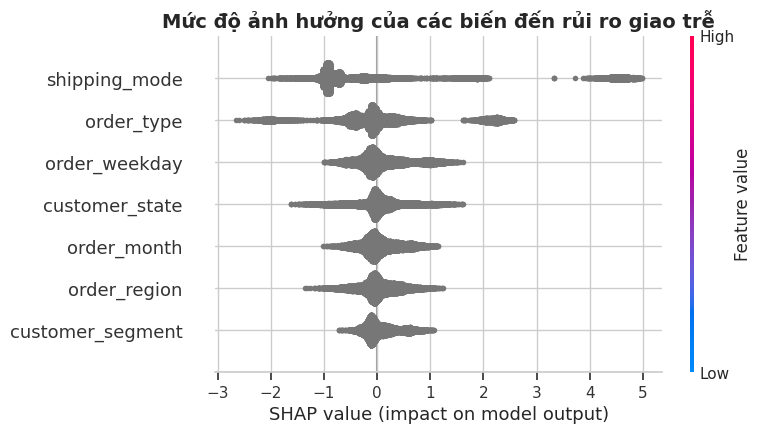


📊 2. GIẢI THÍCH ĐƠN HÀNG RỦI RO NHẤT (Index: 9824, Prob: 100.00%):


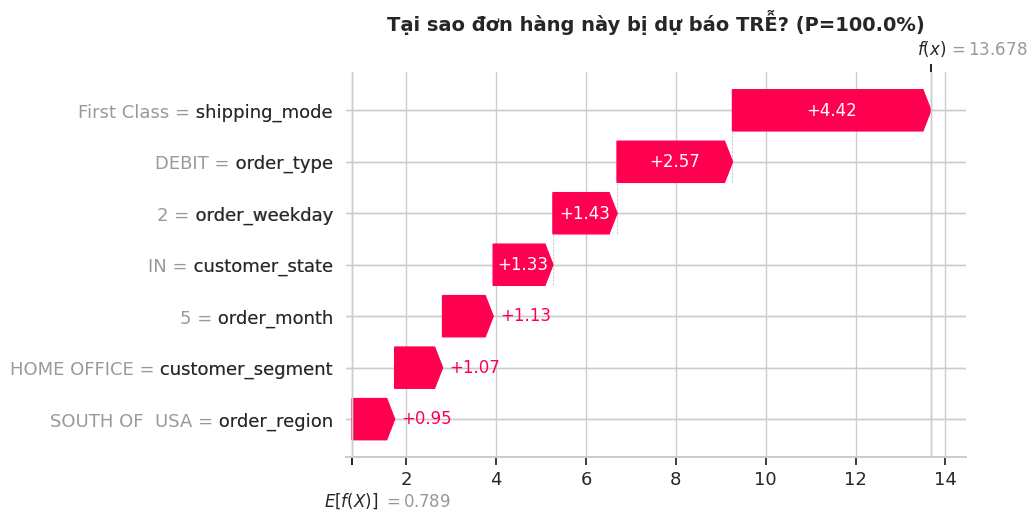


⏳ Đang chuẩn bị dữ liệu để lưu trữ vào MotherDuck...
🚀 Đang đẩy dữ liệu Intelligence lên MotherDuck...
✅ Đã lưu bảng: my_db.main.ml_predictions_explained
✅ Đã lưu bảng: my_db.main.ml_feature_importance
✅ Đã lưu bảng: my_db.main.ml_performance_metrics
✅ Đã lưu bảng: my_db.main.ml_model_blob

🎉 HOÀN THÀNH DỰ ÁN ML! DỮ LIỆU ĐÃ SẴN SÀNG TRÊN CLOUD.


In [ ]:
import shap
import pickle
import base64
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import userdata

# =====================================================
# 1. KẾT NỐI MOTHERDUCK BẰNG KEY TRONG SECRETS
# =====================================================
# Lấy token từ secret (Lưu ý: Bạn kiểm tra lại tên là 'motherduc' hay 'motherduck' trong Secrets nhé)
md_token = userdata.get('motherduck')
con = duckdb.connect(f'md:my_db?motherduck_token={md_token}')

# =====================================================
# 2. TÍNH TOÁN SHAP & HIỂN THỊ HÌNH ẢNH (Intelligence)
# =====================================================
print("⏳ Đang khởi tạo SHAP Explainer...")
explainer = shap.TreeExplainer(final_best_model)
shap_values_obj = explainer(X_test[best_features]) # Tạo object chứa đầy đủ thông tin để vẽ

# --- A. Hiển thị SHAP Global Summary (Ảnh 1) ---
print("\n📊 1. BIỂU ĐỒ GIẢI THÍCH TỔNG THỂ (SHAP Global Summary):")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_obj, X_test[best_features], show=False)
plt.title("Mức độ ảnh hưởng của các biến đến rủi ro giao trễ", fontsize=14, fontweight='bold')
plt.show()

# --- B. Hiển thị SHAP Local - Đơn hàng rủi ro nhất (Ảnh 2) ---
# Tìm index của đơn hàng có xác suất trễ cao nhất để giải thích cho thầy
high_risk_idx = np.argmax(test_prob)
print(f"\n📊 2. GIẢI THÍCH ĐƠN HÀNG RỦI RO NHẤT (Index: {high_risk_idx}, Prob: {test_prob[high_risk_idx]:.2%}):")

plt.figure(figsize=(12, 4))
# Vẽ biểu đồ Waterfall cho đơn hàng rủi ro nhất
shap.waterfall_plot(shap_values_obj[high_risk_idx], show=False)
plt.title(f"Tại sao đơn hàng này bị dự báo TRỄ? (P={test_prob[high_risk_idx]:.1%})", fontsize=14, fontweight='bold')
plt.show()

# =====================================================
# 3. CHUẨN BỊ DỮ LIỆU ĐỂ LƯU TRỮ (Export)
# =====================================================
print("\n⏳ Đang chuẩn bị dữ liệu để lưu trữ vào MotherDuck...")
now_str = pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')

# --- Bảng Predictions có kèm giải thích SHAP ---
df_pred_final = X_test[best_features].copy().reset_index(drop=True)
df_pred_final['order_id'] = df.loc[X_test.index, 'order_id'].values if 'order_id' in df.columns else np.nan
df_pred_final['actual'] = y_test.values
df_pred_final['predicted_probability'] = test_prob
df_pred_final['predicted_label'] = test_pred

# Lưu giá trị SHAP của từng cột (Local Explanation) vào database
shap_local_data = pd.DataFrame(shap_values_obj.values, columns=[f"shap_{col}" for col in best_features])
df_pred_final = pd.concat([df_pred_final, shap_local_data], axis=1)
df_pred_final['created_at'] = now_str

# --- Bảng Feature Importance (Global Explanation) ---
shap_global_df = pd.DataFrame({
    'feature': best_features,
    'importance_score': np.abs(shap_values_obj.values).mean(axis=0)
}).sort_values('importance_score', ascending=False)
shap_global_df['created_at'] = now_str

# --- Bảng Metrics ---
df_metrics = pd.DataFrame([{
    'model_name': 'CatBoost_Final_k8',
    'auc': round(roc_auc_score(y_test, test_prob), 4),
    'f1': round(f1_score(y_test, test_pred), 4),
    'best_threshold': round(best_threshold, 4),
    'created_at': now_str
}])

# --- Lưu Model Blob ---
model_b64 = base64.b64encode(pickle.dumps(final_best_model)).decode('utf-8')
df_model_blob = pd.DataFrame([{
    'model_name': 'late_delivery_model',
    'model_blob': model_b64,
    'features_used': ",".join(best_features),
    'created_at': now_str
}])

# =====================================================
# 4. THỰC HIỆN ĐẨY LÊN MOTHERDUCK
# =====================================================
print(f"🚀 Đang đẩy dữ liệu Intelligence lên MotherDuck...")

export_tables = {
    'ml_predictions_explained': df_pred_final,
    'ml_feature_importance': shap_global_df,
    'ml_performance_metrics': df_metrics,
    'ml_model_blob': df_model_blob
}

for table_name, data in export_tables.items():
    con.register('tmp_table', data)
    con.execute(f"CREATE OR REPLACE TABLE my_db.main.{table_name} AS SELECT * FROM tmp_table")
    print(f"✅ Đã lưu bảng: my_db.main.{table_name}")

print("\n" + "="*50)
print("🎉 HOÀN THÀNH DỰ ÁN ML! DỮ LIỆU ĐÃ SẴN SÀNG TRÊN CLOUD.")
print("="*50)

⏳ Đang tải dữ liệu và Model từ MotherDuck...
📊 1. Đang hiển thị giải thích tổng thể cho 22,838 đơn hàng...


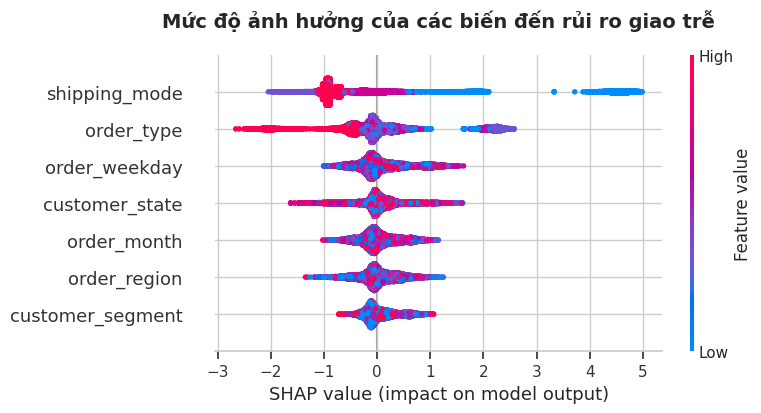


📊 2. Đang tạo giải thích chi tiết cho đơn hàng rủi ro nhất...


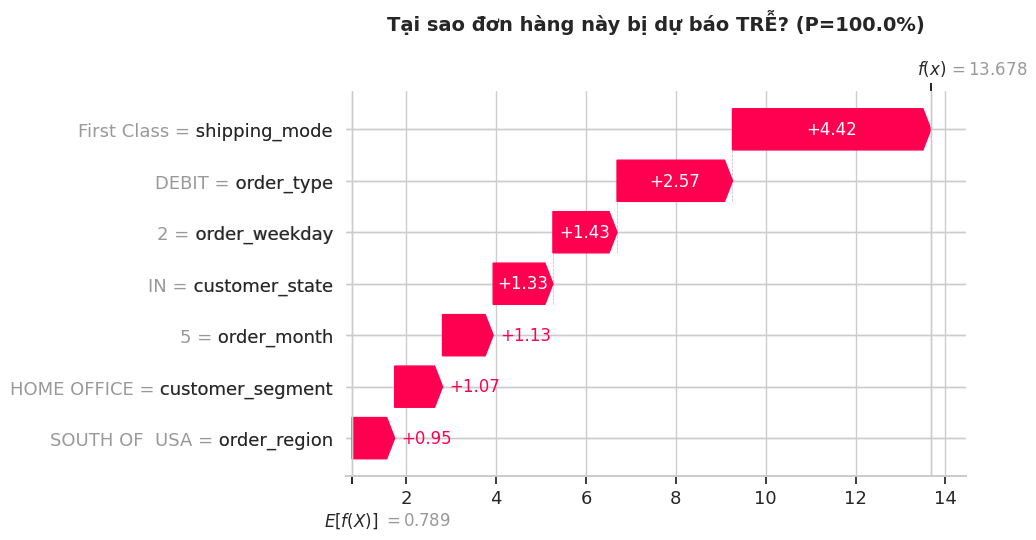


🎉 HOÀN THÀNH! Dữ liệu đã được tái hiện đầy đủ từ MotherDuck.


In [3]:
import duckdb
import pickle
import base64
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from google.colab import userdata

# 1. KẾT NỐI MOTHERDUCK
md_token = userdata.get('motherduck')
con = duckdb.connect(f'md:my_db?motherduck_token={md_token}')

print("⏳ Đang tải dữ liệu và Model từ MotherDuck...")

# 2. LOAD MODEL BLOB (Cần thiết để lấy base_value cho Waterfall plot)
df_model = con.execute("SELECT model_blob, features_used FROM my_db.main.ml_model_blob ORDER BY created_at DESC LIMIT 1").df()
model_raw = base64.b64decode(df_model['model_blob'][0])
loaded_model = pickle.loads(model_raw)
best_features = df_model['features_used'][0].split(',')

# 3. LẤY DỮ LIỆU GIẢI THÍCH (22,838 dòng)
df_explained = con.execute("SELECT * FROM my_db.main.ml_predictions_explained").df()

# 4. TÁCH MA TRẬN SHAP VÀ FEATURE GỐC
shap_values_matrix = df_explained[[f"shap_{col}" for col in best_features]].values
X_original = df_explained[best_features].copy()

# 5. FIX LỖI MÀU XÁM (SUMMARY PLOT)
X_display = X_original.copy()
for col in X_display.columns:
    if X_display[col].dtype == 'object' or X_display[col].dtype.name == 'category':
        X_display[col] = X_display[col].astype('category').cat.codes

# ---------------------------------------------------------
# 6. VẼ HÌNH 1: SHAP SUMMARY PLOT (TỔNG THỂ CÓ MÀU)
# ---------------------------------------------------------
print(f"📊 1. Đang hiển thị giải thích tổng thể cho {len(df_explained):,} đơn hàng...")
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_matrix,
    X_display,
    feature_names=best_features,
    show=False
)
plt.title("Mức độ ảnh hưởng của các biến đến rủi ro giao trễ", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 7. VẼ HÌNH 2: SHAP WATERFALL PLOT (CHO ĐƠN HÀNG RỦI RO NHẤT)
# ---------------------------------------------------------
print("\n📊 2. Đang tạo giải thích chi tiết cho đơn hàng rủi ro nhất...")

# Tìm index đơn hàng rủi ro nhất
high_risk_idx = df_explained['predicted_probability'].idxmax()

# Lấy thông tin model để tính base_value
explainer = shap.TreeExplainer(loaded_model)
# Đối với CatBoost, expected_value có thể là mảng, ta lấy giá trị đầu tiên
base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = base_val[0]

# Tạo đối tượng Explanation để vẽ Waterfall
exp = shap.Explanation(
    values=shap_values_matrix[high_risk_idx],
    base_values=base_val,
    data=X_original.iloc[high_risk_idx],
    feature_names=best_features
)

plt.figure(figsize=(12, 5))
shap.waterfall_plot(exp, show=False)
prob_val = df_explained.loc[high_risk_idx, 'predicted_probability']
plt.title(f"Tại sao đơn hàng này bị dự báo TRỄ? (P={prob_val:.1%})", fontsize=14, fontweight='bold', pad=20)
plt.show()

print("\n🎉 HOÀN THÀNH! Dữ liệu đã được tái hiện đầy đủ từ MotherDuck.")